#### 07 - Model Comparison and Final Evaluation

This notebook presents a systematic comparison of the four image classification approaches implemented in this project:

1. **HOG + Support Vector Machine (SVM)**  
2. **Custom Convolutional Neural Network (CNN)**  
3. **ResNet18 Transfer Learning Model**  
4. **MobileNetV3 Transfer Learning Model**

The models are compared using classification performance, computational efficiency, model complexity, and per-class behaviour.

The objectives of this notebook are to:

- compare the models using consistent test-set metrics;
- examine the improvement over the traditional machine learning baseline;
- compare training time, inference time, and model complexity;
- investigate per-class performance and difficult traffic sign categories;
- evaluate the trade-off between predictive performance and computational cost;
- select the most suitable final model.

All models were evaluated using the same held-out test dataset wherever applicable. No additional model training is performed in this notebook.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

##### 1. Project Configuration

The comparison notebook uses the evaluation results generated in the previous model notebooks.

Where automatically saved result files are unavailable, the final metric values are entered manually from the corresponding notebook outputs. This approach avoids retraining the models and ensures that the reported results remain consistent with the original experiments.

In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Current directory: {CURRENT_DIR}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Figures directory: {FIGURES_DIR}")
print(f"Tables directory: {TABLES_DIR}")

Current directory: /Users/liuyuhan/Desktop/traffic_recognition/notebooks
Project root: /Users/liuyuhan/Desktop/traffic_recognition
Results directory: /Users/liuyuhan/Desktop/traffic_recognition/results
Figures directory: /Users/liuyuhan/Desktop/traffic_recognition/results/figures
Tables directory: /Users/liuyuhan/Desktop/traffic_recognition/results/tables


##### 2. Loading the Overall Model Results

The overall results are loaded from the files produced by the original experiments.

The main evaluation metrics are:

- **Accuracy**: the proportion of all test images classified correctly;
- **Macro precision**: the mean precision across all 43 classes;
- **Macro recall**: the mean recall across all classes;
- **Macro F1-score**: the unweighted mean F1-score across all classes;
- **Weighted F1-score**: the F1-score weighted according to class support.

Macro-averaged metrics are important because they assign equal importance to every class and therefore help identify whether strong overall accuracy is dominated by the larger classes.

In [3]:
result_files = sorted(
    file_path
    for file_path in RESULTS_DIR.iterdir()
    if file_path.is_file()
)

print(f"Number of result files found: {len(result_files)}")
print("-" * 70)

for file_path in result_files:
    print(file_path.name)

Number of result files found: 40
----------------------------------------------------------------------
class_distribution.csv
cnn_baseline_classification_report.csv
cnn_baseline_history.csv
cnn_baseline_per_class_accuracy.csv
cnn_baseline_summary.csv
cnn_baseline_test_predictions.csv
dataset_validation_summary.csv
eda_summary.csv
hog_svm_baseline_experiment_summary.json
hog_svm_baseline_model_metrics.csv
hog_svm_class_mapping.csv
hog_svm_common_classification_errors.csv
hog_svm_per_class_test_performance.csv
hog_svm_test_classification_report.csv
hog_svm_test_predictions.csv
hog_svm_validation_classification_report.csv
mobilenetv3_best_classes.csv
mobilenetv3_class_frequency_performance.csv
mobilenetv3_classification_report.csv
mobilenetv3_common_confusions.csv
mobilenetv3_confusion_matrix_normalised.csv
mobilenetv3_confusion_matrix_raw.csv
mobilenetv3_experiment_summary.csv
mobilenetv3_feature_extraction_history.csv
mobilenetv3_fine_tuning_history.csv
mobilenetv3_overall_metrics.csv


In [4]:
required_files = {
    "HOG + Linear SVM metrics":
        RESULTS_DIR / "hog_svm_baseline_model_metrics.csv",

    "HOG + Linear SVM experiment summary":
        RESULTS_DIR / "hog_svm_baseline_experiment_summary.json",

    "Custom CNN summary":
        RESULTS_DIR / "cnn_baseline_summary.csv",

    "ResNet18 metrics":
        RESULTS_DIR / "resnet18_metrics.json",

    "MobileNetV3 metrics":
        RESULTS_DIR / "mobilenetv3_overall_metrics.csv",

    "MobileNetV3 experiment summary":
        RESULTS_DIR / "mobilenetv3_experiment_summary.csv"
}

all_required_files_found = True

for description, file_path in required_files.items():
    status = "FOUND" if file_path.exists() else "MISSING"
    print(f"{status:8} | {description}")
    print(f"{file_path.name}")

    if not file_path.exists():
        all_required_files_found = False

if all_required_files_found:
    print("\nAll required model result files were found.")
else:
    print(
        "\nSome required files were not found. "
        "Check that Notebooks 03-06 completed successfully."
    )

FOUND    | HOG + Linear SVM metrics
hog_svm_baseline_model_metrics.csv
FOUND    | HOG + Linear SVM experiment summary
hog_svm_baseline_experiment_summary.json
FOUND    | Custom CNN summary
cnn_baseline_summary.csv
FOUND    | ResNet18 metrics
resnet18_metrics.json
FOUND    | MobileNetV3 metrics
mobilenetv3_overall_metrics.csv
FOUND    | MobileNetV3 experiment summary
mobilenetv3_experiment_summary.csv

All required model result files were found.


In [5]:
def read_first_row_csv(file_path):
    """Read a CSV and return its first row as a dictionary."""
    dataframe = pd.read_csv(file_path)

    if dataframe.empty:
        raise ValueError(f"The file is empty: {file_path}")

    return dataframe.iloc[0].to_dict()


def read_json_file(file_path):
    """Read a JSON file and return its content."""
    with open(file_path, "r", encoding="utf-8") as file:
        return json.load(file)


def first_available(dictionary, possible_keys, default=np.nan):
    """
    Return the first available non-null value from a list of
    possible dictionary keys.
    """
    for key in possible_keys:
        if key in dictionary and pd.notna(dictionary[key]):
            return dictionary[key]

    return default


def convert_to_float(value):
    """Convert an available result value to float."""
    if value is None:
        return np.nan

    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan

In [6]:
hog_metrics_path = (RESULTS_DIR / "hog_svm_baseline_model_metrics.csv")

hog_summary_path = (RESULTS_DIR / "hog_svm_baseline_experiment_summary.json")

hog_metrics_file = pd.read_csv(hog_metrics_path)
hog_experiment_summary = read_json_file(hog_summary_path)

display(hog_metrics_file)

,model,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_time_seconds,prediction_time_seconds
0,Majority Class Dummy,Validation,0.0574,0.0013,0.0233,0.0025,0.0062,0.0053,0.0029
1,Majority Class Dummy,Test,0.0594,0.0014,0.0233,0.0026,0.0067,0.0053,0.0006
2,HOG + Linear SVM,Validation,0.9494,0.9555,0.9606,0.9579,0.9492,21142.9302,0.4303
3,HOG + Linear SVM,Test,0.8771,0.8628,0.8655,0.8623,0.8765,21142.9302,0.7525


In [7]:
hog_metrics_lower = hog_metrics_file.copy()
hog_metrics_lower.columns = [
    column.strip().lower()
    for column in hog_metrics_lower.columns
]

# Search for the HOG/SVM test result rather than the dummy baseline.
hog_test_candidates = hog_metrics_lower.copy()

for possible_column in ["model", "model_name"]:
    if possible_column in hog_test_candidates.columns:
        hog_test_candidates = hog_test_candidates[
            hog_test_candidates[possible_column]
            .astype(str)
            .str.contains("hog|svm", case=False, regex=True)
        ]

for possible_column in [
    "dataset_split",
    "split",
    "dataset"
]:
    if possible_column in hog_test_candidates.columns:
        hog_test_candidates = hog_test_candidates[
            hog_test_candidates[possible_column]
            .astype(str)
            .str.contains("test", case=False, regex=False)
        ]

if hog_test_candidates.empty:
    print(
        "The HOG metric row could not be selected automatically. "
        "The known final test values from Notebook 03 will be used."
    )

    hog_result = {
        "accuracy": 0.8771,
        "macro_precision": 0.8628,
        "macro_recall": 0.8655,
        "macro_f1": 0.8623,
        "weighted_f1": 0.8765,
        "training_time_seconds": 21142.93,
        "inference_time_seconds": 0.75
    }

else:
    hog_row = hog_test_candidates.iloc[-1].to_dict()

    hog_result = {
        "accuracy": convert_to_float(
            first_available(
                hog_row,
                ["accuracy", "test_accuracy"]
            )
        ),

        "macro_precision": convert_to_float(
            first_available(
                hog_row,
                ["macro_precision"]
            )
        ),

        "macro_recall": convert_to_float(
            first_available(
                hog_row,
                ["macro_recall"]
            )
        ),

        "macro_f1": convert_to_float(
            first_available(
                hog_row,
                [
                    "macro_f1",
                    "macro_f1_score",
                    "macro f1-score"
                ]
            )
        ),

        "weighted_f1": convert_to_float(
            first_available(
                hog_row,
                [
                    "weighted_f1",
                    "weighted_f1_score"
                ]
            )
        ),

        "training_time_seconds": convert_to_float(
            first_available(
                hog_row,
                [
                    "training_time_seconds",
                    "training_seconds"
                ],
                default=21142.93
            )
        ),

        "inference_time_seconds": convert_to_float(
            first_available(
                hog_row,
                [
                    "prediction_time_seconds",
                    "test_prediction_time",
                    "inference_time_seconds"
                ],
                default=0.75
            )
        )
    }

# The JSON structure may differ slightly, so known experiment values are used only where the CSV did not provide a result.
if np.isnan(hog_result["training_time_seconds"]):
    hog_result["training_time_seconds"] = 21142.93

if np.isnan(hog_result["inference_time_seconds"]):
    hog_result["inference_time_seconds"] = 0.75

hog_result

{'accuracy': 0.8771179730799683,
 'macro_precision': 0.8628344472582256,
 'macro_recall': 0.8655201453977995,
 'macro_f1': 0.8623472406852613,
 'weighted_f1': 0.8765017492963572,
 'training_time_seconds': 21142.930242826,
 'inference_time_seconds': 0.7525272420025431}

In [8]:
cnn_summary_path = RESULTS_DIR / "cnn_baseline_summary.csv"
cnn_summary = read_first_row_csv(cnn_summary_path)

cnn_result = {
    "accuracy": convert_to_float(
        cnn_summary["test_accuracy"]
    ),

    "macro_precision": convert_to_float(
        cnn_summary["macro_precision"]
    ),

    "macro_recall": convert_to_float(
        cnn_summary["macro_recall"]
    ),

    "macro_f1": convert_to_float(
        cnn_summary["macro_f1"]
    ),

    "weighted_f1": convert_to_float(
        cnn_summary["weighted_f1"]
    ),

    "training_time_seconds": convert_to_float(
        cnn_summary["training_time_seconds"]
    ),

    "inference_time_seconds": convert_to_float(
        cnn_summary["prediction_time_seconds"]
    ),

    # Obtained from model.summary() in Notebook 04.
    "total_parameters": 162379,

    # All trainable weights reported by Keras.
    "trainable_parameters": 161931
}

cnn_result

{'accuracy': 0.9696753760886776,
 'macro_precision': 0.9502434587908836,
 'macro_recall': 0.9500499408279994,
 'macro_f1': 0.9473965138534768,
 'weighted_f1': 0.9697644000328632,
 'training_time_seconds': 2140.780647754669,
 'inference_time_seconds': 7.786086797714233,
 'total_parameters': 162379,
 'trainable_parameters': 161931}

In [9]:
resnet_metrics_path = RESULTS_DIR / "resnet18_metrics.json"
resnet_metrics = read_json_file(resnet_metrics_path)

resnet_result = {
    "accuracy": convert_to_float(
        first_available(
            resnet_metrics,
            ["accuracy", "test_accuracy"]
        )
    ),

    "macro_precision": convert_to_float(
        first_available(
            resnet_metrics,
            ["macro_precision"]
        )
    ),

    "macro_recall": convert_to_float(
        first_available(
            resnet_metrics,
            ["macro_recall"]
        )
    ),

    "macro_f1": convert_to_float(
        first_available(
            resnet_metrics,
            [
                "macro_f1",
                "macro_f1_score"
            ]
        )
    ),

    "weighted_f1": convert_to_float(
        first_available(
            resnet_metrics,
            [
                "weighted_f1",
                "weighted_f1_score"
            ]
        )
    ),

    "training_time_seconds": convert_to_float(
        first_available(
            resnet_metrics,
            [
                "total_training_seconds",
                "training_time_seconds"
            ]
        )
    ),

    "inference_time_seconds": convert_to_float(
        first_available(
            resnet_metrics,
            [
                "test_inference_seconds",
                "inference_seconds"
            ]
        )
    ),

    "total_parameters": convert_to_float(
        first_available(
            resnet_metrics,
            ["total_parameters"]
        )
    ),

    "trainable_parameters": convert_to_float(
        first_available(
            resnet_metrics,
            [
                "stage2_trainable_parameters",
                "trainable_parameters"
            ]
        )
    )
}

# Fallback values from the final outputs of Notebook 05.
resnet_fallbacks = {
    "accuracy": 0.9348,
    "macro_precision": 0.9086,
    "macro_recall": 0.9132,
    "macro_f1": 0.9063,
    "weighted_f1": 0.9350,
    "training_time_seconds": 26328.0854,
    "inference_time_seconds": 448.7868,
    "total_parameters": 11198571,
    "trainable_parameters": 8415787
}

for key, fallback_value in resnet_fallbacks.items():
    if np.isnan(resnet_result[key]):
        resnet_result[key] = fallback_value

resnet_result

{'accuracy': 0.9347585114806017,
 'macro_precision': 0.908648120080536,
 'macro_recall': 0.9132000395870464,
 'macro_f1': 0.9063484484804847,
 'weighted_f1': 0.9349685960116381,
 'training_time_seconds': 26328.085416078568,
 'inference_time_seconds': 448.7868287563324,
 'total_parameters': 11198571.0,
 'trainable_parameters': 8415787.0}

In [10]:
mobilenet_metrics_path = (RESULTS_DIR / "mobilenetv3_overall_metrics.csv")

mobilenet_summary_path = (RESULTS_DIR / "mobilenetv3_experiment_summary.csv")

mobilenet_metrics = read_first_row_csv(mobilenet_metrics_path)

mobilenet_summary = read_first_row_csv(mobilenet_summary_path)

mobilenet_result = {
    "accuracy": convert_to_float(
        first_available(
            mobilenet_metrics,
            ["accuracy", "test_accuracy"]
        )
    ),

    "macro_precision": convert_to_float(
        mobilenet_metrics["macro_precision"]
    ),

    "macro_recall": convert_to_float(
        mobilenet_metrics["macro_recall"]
    ),

    "macro_f1": convert_to_float(
        mobilenet_metrics["macro_f1"]
    ),

    "weighted_f1": convert_to_float(
        first_available(
            mobilenet_metrics,
            ["weighted_f1"]
        )
    ),

    "training_time_seconds": convert_to_float(
        first_available(
            mobilenet_summary,
            [
                "total_training_time_seconds",
                "total_training_seconds"
            ]
        )
    ),

    "inference_time_seconds": convert_to_float(
        first_available(
            mobilenet_metrics,
            [
                "inference_time_seconds",
                "test_inference_seconds"
            ]
        )
    ),

    "total_parameters": convert_to_float(
        first_available(
            mobilenet_metrics,
            ["total_parameters"]
        )
    ),

    "trainable_parameters": convert_to_float(
        first_available(
            mobilenet_metrics,
            [
                "trainable_parameters_final_stage",
                "trainable_parameters"
            ]
        )
    )
}

mobilenet_result

{'accuracy': 0.8906571654790182,
 'macro_precision': 0.8487313193639564,
 'macro_recall': 0.8271700514966439,
 'macro_f1': 0.8325521087935405,
 'weighted_f1': 0.890309342454531,
 'training_time_seconds': 56261.62965273857,
 'inference_time_seconds': 331.2344501018524,
 'total_parameters': 4257115.0,
 'trainable_parameters': 3035403.0}

In [11]:
model_results = [
    {
        "model": "HOG + Linear SVM",
        **hog_result,
        "total_parameters": np.nan,
        "trainable_parameters": np.nan,
        "input_size": "32 x 32"
    },

    {
        "model": "Custom CNN",
        **cnn_result,
        "input_size": "32 x 32"
    },

    {
        "model": "ResNet18",
        **resnet_result,
        "input_size": "224 x 224"
    },

    {
        "model": "MobileNetV3-Large",
        **mobilenet_result,
        "input_size": "224 x 224"
    }
]

results_df = pd.DataFrame(model_results)

results_df["training_time_minutes"] = (results_df["training_time_seconds"] / 60)

results_df["mean_inference_ms_per_image"] = (results_df["inference_time_seconds"] / 12630 * 1000)

results_df["parameters_millions"] = (results_df["total_parameters"] / 1_000_000)

display(results_df.round(4))

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_time_seconds,inference_time_seconds,total_parameters,trainable_parameters,input_size,training_time_minutes,mean_inference_ms_per_image,parameters_millions
0,HOG + Linear SVM,0.8771,0.8628,0.8655,0.8623,0.8765,21142.9302,0.7525,NaN,NaN,32 x 32,352.3822,0.0596,NaN
1,Custom CNN,0.9697,0.9502,0.9500,0.9474,0.9698,2140.7806,7.7861,162379.0000,161931.0000,32 x 32,35.6797,0.6165,0.1624
2,ResNet18,0.9348,0.9086,0.9132,0.9063,0.9350,26328.0854,448.7868,11198571.0000,8415787.0000,224 x 224,438.8014,35.5334,11.1986
3,MobileNetV3-Large,0.8907,0.8487,0.8272,0.8326,0.8903,56261.6297,331.2345,4257115.0000,3035403.0000,224 x 224,937.6938,26.2260,4.2571


##### 3. Overall Test-Set Performance

The four models were evaluated on the same held-out test set containing 12,630 images across 43 traffic sign classes.

The custom CNN achieved the strongest test performance:

- **Custom CNN:** 96.97% accuracy and 94.74% macro F1-score;
- **ResNet18:** 93.48% accuracy and 90.63% macro F1-score;
- **MobileNetV3-Large:** 89.07% accuracy and 83.26% macro F1-score;
- **HOG + Linear SVM:** 87.71% accuracy and 86.23% macro F1-score.

The result shows that transfer learning did not automatically produce the best performance in this experiment. The custom CNN trained specifically on the traffic sign dataset outperformed both pretrained architectures.

In [12]:
performance_table = results_df[
    [
        "model",
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "weighted_f1"
    ]
].copy()

metric_columns = [
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1"
]

for column in metric_columns:
    performance_table[column] *= 100

performance_table = performance_table.rename(
    columns={
        "model": "Model",
        "accuracy": "Accuracy (%)",
        "macro_precision": "Macro Precision (%)",
        "macro_recall": "Macro Recall (%)",
        "macro_f1": "Macro F1-score (%)",
        "weighted_f1": "Weighted F1-score (%)"
    }
)

performance_table = performance_table.sort_values(by="Accuracy (%)", ascending=False).reset_index(drop=True)

display(performance_table.round(2))

,Model,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1-score (%),Weighted F1-score (%)
0,Custom CNN,96.9700,95.0200,95.0000,94.7400,96.9800
1,ResNet18,93.4800,90.8600,91.3200,90.6300,93.5000
2,MobileNetV3-Large,89.0700,84.8700,82.7200,83.2600,89.0300
3,HOG + Linear SVM,87.7100,86.2800,86.5500,86.2300,87.6500


In [13]:
performance_table_path = (TABLES_DIR / "overall_model_performance.csv")

performance_table.to_csv(performance_table_path, index=False)

print(f"Performance table saved to: "f"{performance_table_path}")

Performance table saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/tables/overall_model_performance.csv


##### Interpretation of Overall Performance

The **custom CNN** achieved the highest test accuracy of **96.97%**, followed by **ResNet18 at 93.48%**. The difference between these models was approximately **3.49 percentage points**.

MobileNetV3-Large achieved **89.07%**, which was only 1.36 percentage points higher than the HOG + Linear SVM baseline. Its macro F1-score of **83.26%** was also lower than the HOG-SVM macro F1-score of **86.23%**. This indicates that MobileNetV3 produced less consistent performance across the 43 classes.

The custom CNN achieved a macro F1-score of **94.74%**, showing strong and comparatively balanced performance across the classes. Its weighted F1-score of approximately **96.98%** was close to its overall accuracy.

The results suggest that a relatively compact CNN trained directly on the target dataset was more effective than the selected ImageNet-pretrained architectures under the experimental conditions used in this project.

##### 4. Visual Comparison of Evaluation Metrics

The following figure compares test accuracy, macro precision, macro recall, and macro F1-score.

Scores that remain close across the four metrics indicate more balanced performance. A larger gap between accuracy and macro F1-score can indicate that a model performs well on frequent classes but less consistently on smaller or more difficult classes.

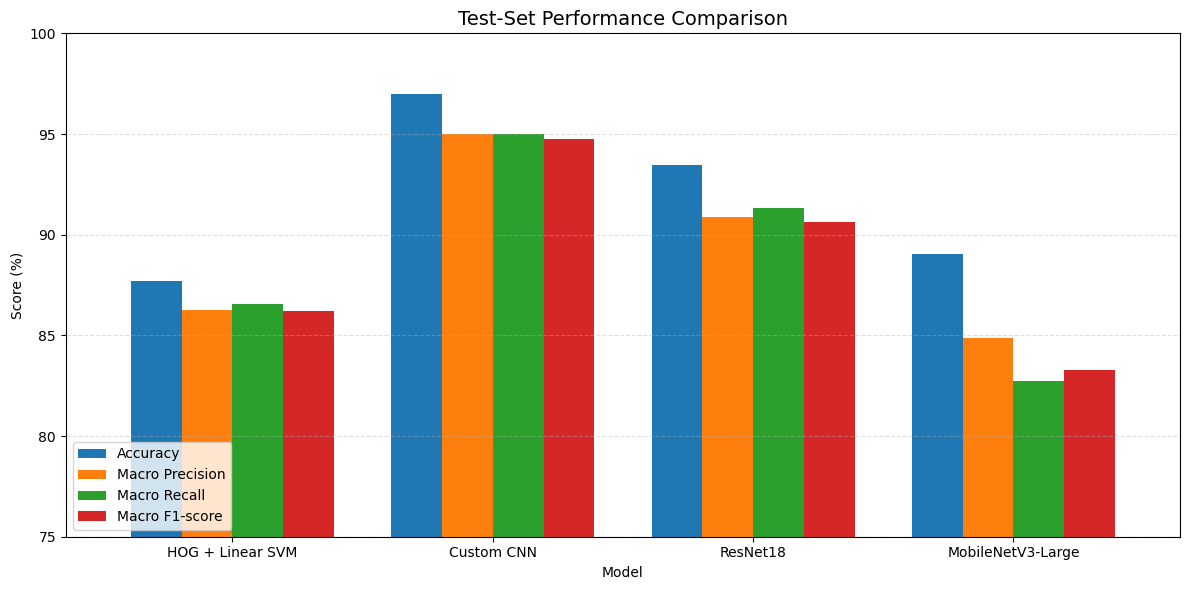

Figure saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/07_overall_performance_comparison.png


In [14]:
performance_plot_df = (results_df.set_index("model")[["accuracy", "macro_precision", "macro_recall", "macro_f1"]] * 100)

ax = performance_plot_df.plot(kind="bar", figsize=(12, 6), width=0.78)

ax.set_title("Test-Set Performance Comparison", fontsize=14)
ax.set_xlabel("Model")
ax.set_ylabel("Score (%)")
ax.set_ylim(75, 100)
ax.tick_params(axis="x", rotation=0)

ax.legend(["Accuracy", "Macro Precision", "Macro Recall", "Macro F1-score"], loc="lower left")

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

overall_performance_figure_path = (FIGURES_DIR / "07_overall_performance_comparison.png")

plt.savefig(overall_performance_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: "f"{overall_performance_figure_path}")

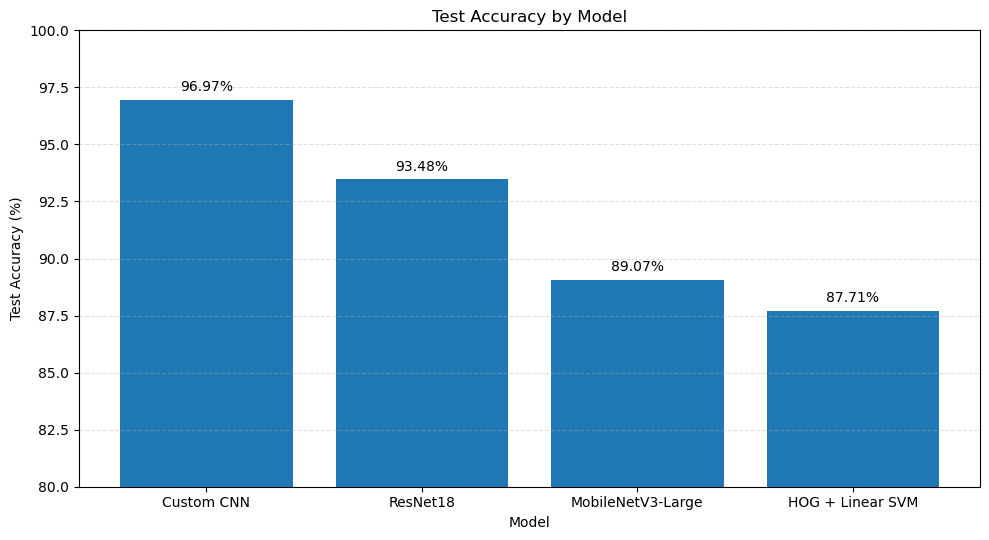

Figure saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/07_test_accuracy_comparison.png


In [15]:
accuracy_plot_df = (results_df[["model", "accuracy"]].sort_values("accuracy", ascending=False))

plt.figure(figsize=(10, 5.5))

bars = plt.bar(accuracy_plot_df["model"], accuracy_plot_df["accuracy"] * 100)

plt.title("Test Accuracy by Model")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.ylim(80, 100)
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar, accuracy in zip(bars, accuracy_plot_df["accuracy"] * 100):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.25,
        f"{accuracy:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

accuracy_figure_path = (FIGURES_DIR / "07_test_accuracy_comparison.png")

plt.savefig(accuracy_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {accuracy_figure_path}")

##### Performance Comparison Discussion

The custom CNN achieved the strongest result across all four main evaluation metrics.

ResNet18 was the strongest transfer learning model, but it remained below the custom CNN in accuracy, precision, recall, and macro F1-score.

MobileNetV3 showed the largest difference between its accuracy and macro F1-score. Its accuracy was 89.07%, while its macro F1-score was 83.26%. This suggests that its overall result was partly supported by stronger performance on the more frequent classes, while several smaller classes remained difficult.

HOG + Linear SVM achieved lower accuracy than MobileNetV3 but a higher macro F1-score. Therefore, the traditional baseline produced a more even class-level result than MobileNetV3 despite having slightly lower overall accuracy.

##### 5. Model Ranking

Accuracy is used as the primary ranking metric because the main objective is correct traffic sign classification.

Macro F1-score is used as a secondary metric because it evaluates performance across all classes without allowing large classes to dominate the result.

In [16]:
ranking_df = results_df[["model", "accuracy", "macro_f1"]].copy()

ranking_df["accuracy_rank"] = (ranking_df["accuracy"].rank(ascending=False, method="min"))

ranking_df["macro_f1_rank"] = (ranking_df["macro_f1"].rank(ascending=False, method="min"))

ranking_df["mean_rank"] = (ranking_df[["accuracy_rank", "macro_f1_rank"]].mean(axis=1))

ranking_df = ranking_df.sort_values(by=["mean_rank", "accuracy"], ascending=[True, False]).reset_index(drop=True)

ranking_df.insert(0, "position", np.arange( 1, len(ranking_df) + 1))

ranking_display = ranking_df.copy()

ranking_display["accuracy"] *= 100
ranking_display["macro_f1"] *= 100

ranking_display = ranking_display.rename(
    columns={
        "position": "Position",
        "model": "Model",
        "accuracy": "Accuracy (%)",
        "macro_f1": "Macro F1-score (%)",
        "accuracy_rank": "Accuracy Rank",
        "macro_f1_rank": "Macro F1 Rank",
        "mean_rank": "Mean Rank"
    }
)

display(ranking_display.round(2))

,Position,Model,Accuracy (%),Macro F1-score (%),Accuracy Rank,Macro F1 Rank,Mean Rank
0,1,Custom CNN,96.9700,94.7400,1.0000,1.0000,1.0000
1,2,ResNet18,93.4800,90.6300,2.0000,2.0000,2.0000
2,3,MobileNetV3-Large,89.0700,83.2600,3.0000,4.0000,3.5000
3,4,HOG + Linear SVM,87.7100,86.2300,4.0000,3.0000,3.5000


In [17]:
best_model = ranking_df.iloc[0]

print("Best overall model")
print("-" * 40)
print(f"Model: {best_model['model']}")
print(f"Test accuracy: "f"{best_model['accuracy'] * 100:.2f}%")
print(f"Macro F1-score: "f"{best_model['macro_f1'] * 100:.2f}%")

Best overall model
----------------------------------------
Model: Custom CNN
Test accuracy: 96.97%
Macro F1-score: 94.74%


##### 6. Improvement over the Traditional Baseline

The HOG + Linear SVM model is used as the traditional machine learning baseline.

Absolute accuracy improvement is calculated in percentage points.

In [18]:
hog_accuracy = results_df.loc[results_df["model"] == "HOG + Linear SVM", "accuracy"].iloc[0]

improvement_df = results_df[["model", "accuracy", "macro_f1"]].copy()

improvement_df["accuracy_improvement_pp"] = (improvement_df["accuracy"] - hog_accuracy) * 100

improvement_df["relative_accuracy_improvement"] = ((improvement_df["accuracy"] - hog_accuracy) / hog_accuracy * 100)

improvement_df["accuracy"] *= 100
improvement_df["macro_f1"] *= 100

improvement_df = improvement_df.rename(
    columns={
        "model": "Model",
        "accuracy": "Accuracy (%)",
        "macro_f1": "Macro F1-score (%)",
        "accuracy_improvement_pp":
            "Accuracy Improvement (percentage points)",
        "relative_accuracy_improvement":
            "Relative Accuracy Improvement (%)"
    }
)

display(improvement_df.sort_values("Accuracy (%)", ascending=False).round(2))

,Model,Accuracy (%),Macro F1-score (%),Accuracy Improvement (percentage points),Relative Accuracy Improvement (%)
1,Custom CNN,96.9700,94.7400,9.2600,10.5500
2,ResNet18,93.4800,90.6300,5.7600,6.5700
3,MobileNetV3-Large,89.0700,83.2600,1.3500,1.5400
0,HOG + Linear SVM,87.7100,86.2300,0.0000,0.0000


##### Improvement over HOG + Linear SVM

Compared with the HOG-SVM baseline:

- the custom CNN improved accuracy by approximately **9.26 percentage points**;
- ResNet18 improved accuracy by approximately **5.77 percentage points**;
- MobileNetV3-Large improved accuracy by approximately **1.36 percentage points**.

The custom CNN therefore produced the largest improvement over the traditional baseline.

However, MobileNetV3 did not improve every metric. Although its accuracy was slightly higher than HOG-SVM, its macro precision, macro recall, and macro F1-score were lower. This indicates that the small improvement in overall accuracy did not represent a consistent improvement across all classes.

##### 7. Computational Efficiency

Predictive performance is not the only consideration when selecting a model. Training time, inference time, model size, and hardware requirements are also important.

All experiments were performed locally using CPU-based execution. The recorded times should therefore be interpreted as practical measurements from this project rather than universal architecture benchmarks.

The models also used different input resolutions:

- HOG-SVM and the custom CNN used 32 × 32 images;
- ResNet18 and MobileNetV3 used 224 × 224 images.

The larger transfer learning input size substantially increased computational cost.

In [19]:
efficiency_table = results_df[
    [
        "model",
        "input_size",
        "training_time_minutes",
        "inference_time_seconds",
        "mean_inference_ms_per_image",
        "total_parameters",
        "parameters_millions"
    ]
].copy()

efficiency_table = efficiency_table.rename(
    columns={
        "model": "Model",
        "input_size": "Input Size",
        "training_time_minutes":
            "Training Time (minutes)",
        "inference_time_seconds":
            "Test Inference Time (seconds)",
        "mean_inference_ms_per_image":
            "Mean Inference Time (ms/image)",
        "total_parameters":
            "Total Parameters",
        "parameters_millions":
            "Parameters (millions)"
    }
)

display(efficiency_table.round(3))

,Model,Input Size,Training Time (minutes),Test Inference Time (seconds),Mean Inference Time (ms/image),Total Parameters,Parameters (millions)
0,HOG + Linear SVM,32 x 32,352.3820,0.7530,0.0600,NaN,NaN
1,Custom CNN,32 x 32,35.6800,7.7860,0.6160,162379.0000,0.1620
2,ResNet18,224 x 224,438.8010,448.7870,35.5330,11198571.0000,11.1990
3,MobileNetV3-Large,224 x 224,937.6940,331.2340,26.2260,4257115.0000,4.2570


In [20]:
efficiency_table_path = (TABLES_DIR / "model_efficiency_comparison.csv")

efficiency_table.to_csv(efficiency_table_path, index=False)

print(f"Efficiency table saved to: "f"{efficiency_table_path}")

Efficiency table saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/tables/model_efficiency_comparison.csv


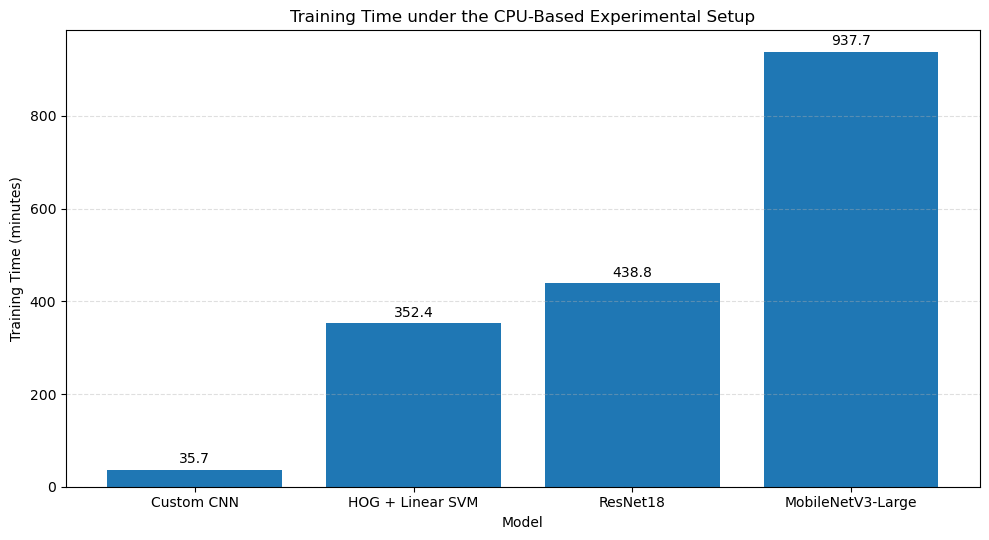

Figure saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/07_training_time_comparison.png


In [21]:
training_time_plot_df = (results_df[["model", "training_time_minutes"]].dropna().sort_values("training_time_minutes", ascending=True))

plt.figure(figsize=(10, 5.5))

bars = plt.bar(training_time_plot_df["model"], training_time_plot_df["training_time_minutes"])

plt.title("Training Time under the CPU-Based Experimental Setup")
plt.xlabel("Model")
plt.ylabel("Training Time (minutes)")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar, time_minutes in zip(bars, training_time_plot_df["training_time_minutes"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8,
        f"{time_minutes:.1f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

training_time_figure_path = (FIGURES_DIR / "07_training_time_comparison.png")

plt.savefig(training_time_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: "f"{training_time_figure_path}")

##### Training-Time Interpretation

The custom CNN was the fastest trained predictive model, completing training in approximately **35.68 minutes**.

The other recorded training times were:

- HOG + Linear SVM: approximately **352.38 minutes**;
- ResNet18: approximately **438.80 minutes**;
- MobileNetV3-Large: approximately **937.69 minutes**.

MobileNetV3 required the longest total training time in this experiment. One unusually long feature-extraction epoch also contributed substantially to its total time. Therefore, the result should not be interpreted as proof that MobileNetV3 is universally slower than ResNet18.

Nevertheless, under the actual local CPU setup used in this project, MobileNetV3 did not provide the expected computational advantage. Its larger 224 × 224 input size and two-stage training procedure made it considerably more expensive than the 32 × 32 custom CNN.

##### 8. Neural Network Model Complexity

The number of parameters provides an approximate indication of model storage and memory requirements.

The parameter count of the HOG-SVM model is not directly comparable with the neural network parameter counts because an SVM uses a different internal representation. It is therefore omitted from this comparison.

In [22]:
complexity_df = (results_df[["model", "total_parameters", "trainable_parameters", "parameters_millions"]].dropna(subset=["total_parameters"]).copy())

complexity_display = complexity_df.rename(
    columns={
        "model": "Model",
        "total_parameters": "Total Parameters",
        "trainable_parameters":
            "Trainable Parameters in Final Stage",
        "parameters_millions":
            "Total Parameters (millions)"
    }
)

display(complexity_display.round(3))

,Model,Total Parameters,Trainable Parameters in Final Stage,Total Parameters (millions)
1,Custom CNN,162379.0000,161931.0000,0.1620
2,ResNet18,11198571.0000,8415787.0000,11.1990
3,MobileNetV3-Large,4257115.0000,3035403.0000,4.2570


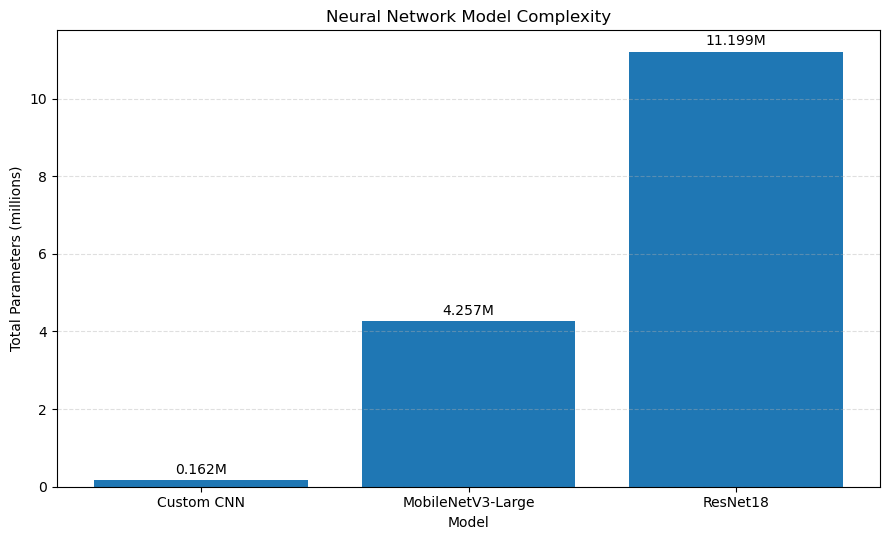

Figure saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/07_model_complexity_comparison.png


In [23]:
complexity_plot_df = (complexity_df.sort_values("parameters_millions", ascending=True))

plt.figure(figsize=(9, 5.5))

bars = plt.bar(complexity_plot_df["model"], complexity_plot_df["parameters_millions"])

plt.title("Neural Network Model Complexity")
plt.xlabel("Model")
plt.ylabel("Total Parameters (millions)")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar, parameter_count in zip(bars, complexity_plot_df["parameters_millions"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{parameter_count:.3f}M",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

complexity_figure_path = (FIGURES_DIR / "07_model_complexity_comparison.png")

plt.savefig(complexity_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: "f"{complexity_figure_path}")

##### Model Complexity Interpretation

The custom CNN contained approximately **0.162 million parameters**, compared with:

- **4.257 million** parameters in MobileNetV3-Large;
- **11.199 million** parameters in ResNet18.

Despite having substantially fewer parameters, the custom CNN achieved the highest test accuracy and macro F1-score.

This result indicates that the traffic sign task did not require the complexity of the larger pretrained models under the current dataset and preprocessing configuration. The compact CNN was sufficiently expressive to learn the relevant colour, edge, shape, and symbol features while avoiding unnecessary computational cost.

##### 9. Accuracy–Complexity Trade-off

An effective model should ideally achieve high accuracy with relatively low complexity.

In the following figure, models towards the upper-left region provide the strongest balance: higher accuracy with fewer parameters.

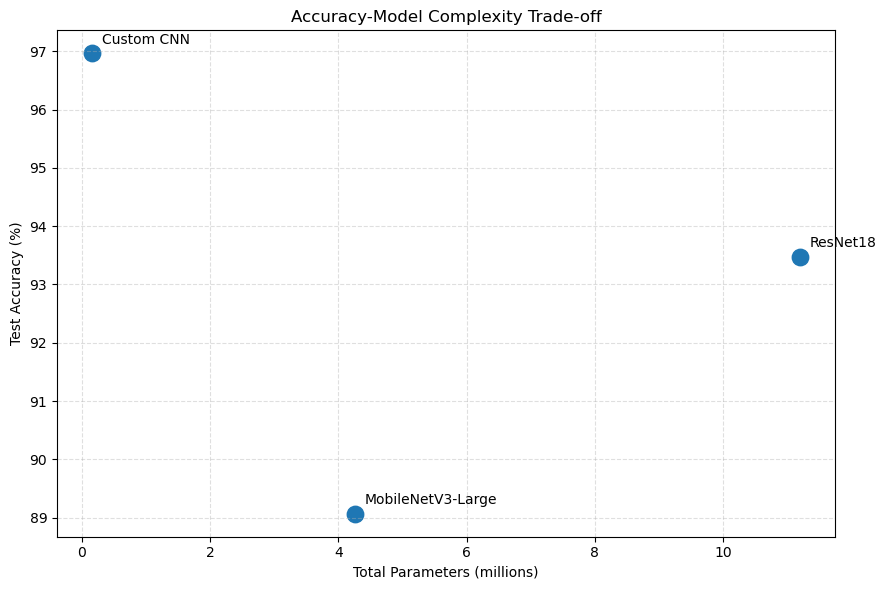

Figure saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/07_accuracy_complexity_tradeoff.png


In [24]:
tradeoff_df = (results_df.dropna(subset=["accuracy", "parameters_millions"]).copy())

plt.figure(figsize=(9, 6))

plt.scatter(tradeoff_df["parameters_millions"], tradeoff_df["accuracy"] * 100, s=140)

for _, row in tradeoff_df.iterrows():
    plt.annotate(row["model"], (row["parameters_millions"], row["accuracy"] * 100), xytext=(7, 7), textcoords="offset points")

plt.title("Accuracy-Model Complexity Trade-off")
plt.xlabel("Total Parameters (millions)")
plt.ylabel("Test Accuracy (%)")
plt.grid(linestyle="--", alpha=0.4)

plt.tight_layout()

tradeoff_figure_path = (FIGURES_DIR / "07_accuracy_complexity_tradeoff.png")

plt.savefig(tradeoff_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: " f"{tradeoff_figure_path}")

##### Accuracy–Complexity Discussion

The custom CNN provided the strongest accuracy-to-complexity trade-off.

It achieved **96.97% accuracy** using only approximately **0.162 million parameters**. ResNet18 achieved 93.48% with approximately 11.20 million parameters, while MobileNetV3 achieved 89.07% with approximately 4.26 million parameters.

Therefore, neither transfer learning model produced an accuracy gain that justified its additional complexity in this experiment.

MobileNetV3 was smaller than ResNet18, as expected from its lightweight architecture, but it was still approximately 26 times larger than the custom CNN and achieved lower classification performance.

##### 10. Per-Class Performance Comparison

Overall accuracy can conceal major differences between classes.

The previous notebooks saved class-level results in different formats:

- HOG-SVM saved per-class test recall;
- the custom CNN saved per-class accuracy, which is equivalent to recall for each true class;
- ResNet18 saved precision, recall, and F1-score;
- MobileNetV3 saved precision, recall, and F1-score.

These files are standardised below so that recall can be compared consistently across all four models.

In [25]:
hog_per_class_path = (RESULTS_DIR / "hog_svm_per_class_test_performance.csv")

cnn_per_class_path = (RESULTS_DIR / "cnn_baseline_per_class_accuracy.csv")

resnet_per_class_path = (RESULTS_DIR / "resnet18_per_class_results.csv")

mobilenet_per_class_path = (RESULTS_DIR / "mobilenetv3_per_class_performance.csv")

per_class_paths = {
    "HOG + Linear SVM": hog_per_class_path,
    "Custom CNN": cnn_per_class_path,
    "ResNet18": resnet_per_class_path,
    "MobileNetV3-Large": mobilenet_per_class_path
}

for model_name, file_path in per_class_paths.items():
    status = "FOUND" if file_path.exists() else "MISSING"
    print(f"{status:8} | {model_name}")
    print(f"{file_path.name}")

FOUND    | HOG + Linear SVM
hog_svm_per_class_test_performance.csv
FOUND    | Custom CNN
cnn_baseline_per_class_accuracy.csv
FOUND    | ResNet18
resnet18_per_class_results.csv
FOUND    | MobileNetV3-Large
mobilenetv3_per_class_performance.csv


In [26]:
# HOG + Linear SVM
hog_per_class = pd.read_csv(hog_per_class_path)

hog_standardised = pd.DataFrame({
    "class_id": hog_per_class["class_index"].astype(int),
    "class_name": hog_per_class["class_name"],
    "HOG + Linear SVM": hog_per_class["test_recall"],
    "support": hog_per_class["test_support"]
})


# Custom CNN
cnn_per_class = pd.read_csv(cnn_per_class_path)

cnn_standardised = pd.DataFrame({
    "class_id": cnn_per_class["class_id"].astype(int),
    "Custom CNN": cnn_per_class["class_accuracy"]
})


# ResNet18
resnet_per_class = pd.read_csv(resnet_per_class_path)

resnet_class_id_column = (
    "original_class_id"
    if "original_class_id" in resnet_per_class.columns
    else "class_index"
)

resnet_standardised = pd.DataFrame({
    "class_id":
        resnet_per_class[
            resnet_class_id_column
        ].astype(int),

    "ResNet18":
        resnet_per_class["recall"]
})


# MobileNetV3
mobilenet_per_class = pd.read_csv(mobilenet_per_class_path)

mobilenet_class_id_column = (
    "original_class"
    if "original_class"
    in mobilenet_per_class.columns
    else "encoded_class"
)

mobilenet_standardised = pd.DataFrame({
    "class_id":
        mobilenet_per_class[
            mobilenet_class_id_column
        ].astype(int),

    "MobileNetV3-Large":
        mobilenet_per_class["recall"]
})


# Merge all models
per_class_comparison = (
    hog_standardised
    .merge(
        cnn_standardised,
        on="class_id",
        how="outer"
    )
    .merge(
        resnet_standardised,
        on="class_id",
        how="outer"
    )
    .merge(
        mobilenet_standardised,
        on="class_id",
        how="outer"
    )
    .sort_values("class_id")
    .reset_index(drop=True)
)

model_recall_columns = [
    "HOG + Linear SVM",
    "Custom CNN",
    "ResNet18",
    "MobileNetV3-Large"
]

per_class_comparison["mean_recall"] = (per_class_comparison[model_recall_columns].mean(axis=1))

per_class_comparison["recall_standard_deviation"] = (per_class_comparison[model_recall_columns].std(axis=1))

display(per_class_comparison.round(4))

,class_id,class_name,HOG + Linear SVM,support,Custom CNN,ResNet18,MobileNetV3-Large,mean_recall,recall_standard_deviation
0,0,0,0.6333,60,1.0000,0.8667,0.7833,0.8208,0.1536
1,1,1,0.8083,720,0.9986,0.8403,0.8792,0.8816,0.0832
2,2,2,0.8253,750,0.9960,0.9440,0.9053,0.9177,0.0719
3,3,3,0.7556,450,0.9844,0.8533,0.7667,0.8400,0.1058
4,4,4,0.8939,660,0.9803,0.9742,0.9258,0.9436,0.0411
5,5,5,0.6968,630,0.9841,0.9127,0.7571,0.8377,0.1334
6,6,6,0.8000,150,1.0000,0.8733,0.7867,0.8650,0.0977
7,7,7,0.8378,450,0.9978,0.9622,0.9733,0.9428,0.0716
8,8,8,0.8089,450,1.0000,0.8956,0.8667,0.8928,0.0800
9,9,9,0.9583,480,0.9958,0.9875,0.9833,0.9812,0.0161


In [27]:
print("Number of classes in combined comparison:", len(per_class_comparison))

print("Class ID range:", per_class_comparison["class_id"].min(), "to", per_class_comparison["class_id"].max())

missing_values = (per_class_comparison[model_recall_columns].isna().sum())

print("\nMissing per-class recall values:")
display(missing_values.to_frame("Missing Values"))

Number of classes in combined comparison: 43
Class ID range: 0 to 42

Missing per-class recall values:


,Missing Values
HOG + Linear SVM,0
Custom CNN,0
ResNet18,0
MobileNetV3-Large,0


In [28]:
best_average_classes = (per_class_comparison.sort_values("mean_recall", ascending=False).head(10))

worst_average_classes = (per_class_comparison.sort_values("mean_recall", ascending=True).head(10))

print("Classes with the highest mean recall")
print("-" * 50)

display(
    best_average_classes[
        [
            "class_id",
            "class_name",
            "support",
            "mean_recall",
            "recall_standard_deviation"
        ]
    ].round(4)
)

print("\nClasses with the lowest mean recall")
print("-" * 50)

display(
    worst_average_classes[
        [
            "class_id",
            "class_name",
            "support",
            "mean_recall",
            "recall_standard_deviation"
        ]
    ].round(4)
)

Classes with the highest mean recall
--------------------------------------------------


,class_id,class_name,support,mean_recall,recall_standard_deviation
13,13,13,720,0.9941,0.0035
14,14,14,270,0.9843,0.0266
9,9,9,480,0.9812,0.0161
32,32,32,60,0.9792,0.0417
15,15,15,210,0.9786,0.0176
10,10,10,660,0.9777,0.0267
12,12,12,690,0.9746,0.0315
31,31,31,270,0.9713,0.0172
16,16,16,150,0.9700,0.0207
38,38,38,690,0.9623,0.0301



Classes with the lowest mean recall
--------------------------------------------------


,class_id,class_name,support,mean_recall,recall_standard_deviation
30,30,30,150,0.6450,0.1170
21,21,21,90,0.6694,0.2001
27,27,27,60,0.7333,0.2152
42,42,42,90,0.7472,0.0190
22,22,22,120,0.7646,0.0558
37,37,37,60,0.7958,0.2266
36,36,36,120,0.8021,0.1896
0,0,0,60,0.8208,0.1536
29,29,29,90,0.8361,0.1208
5,5,5,630,0.8377,0.1334


In [29]:
for model_name in model_recall_columns:
    model_class_results = (
        per_class_comparison[
            [
                "class_id",
                "class_name",
                "support",
                model_name
            ]
        ]
        .sort_values(
            model_name,
            ascending=False
        )
    )

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print("\nFive highest-recall classes:")
    display(model_class_results.head(5).round(4))

    print("\nFive lowest-recall classes:")
    display(model_class_results.tail(5).sort_values(model_name, ascending=True).round(4))

HOG + Linear SVM

Five highest-recall classes:


,class_id,class_name,support,HOG + Linear SVM
19,19,19,60,1.0000
39,39,39,90,1.0000
13,13,13,720,0.9903
12,12,12,690,0.9884
33,33,33,210,0.9762



Five lowest-recall classes:


,class_id,class_name,support,HOG + Linear SVM
30,30,30,150,0.5267
0,0,0,60,0.6333
5,5,5,630,0.6968
41,41,41,60,0.7333
21,21,21,90,0.7333


Custom CNN

Five highest-recall classes:


...

,class_id,class_name,support,ResNet18
30,30,30,150,0.6267
36,36,36,120,0.7167
42,42,42,90,0.7222
22,22,22,120,0.7833
29,29,29,90,0.8000


MobileNetV3-Large

Five highest-recall classes:


,class_id,class_name,support,MobileNetV3-Large
32,32,32,60,1.0000
14,14,14,270,0.9963
13,13,13,720,0.9944
12,12,12,690,0.9899
10,10,10,660,0.9879



Five lowest-recall classes:


,class_id,class_name,support,MobileNetV3-Large
21,21,21,90,0.4000
27,27,27,60,0.4500
37,37,37,60,0.4667
36,36,36,120,0.5750
20,20,20,90,0.5889


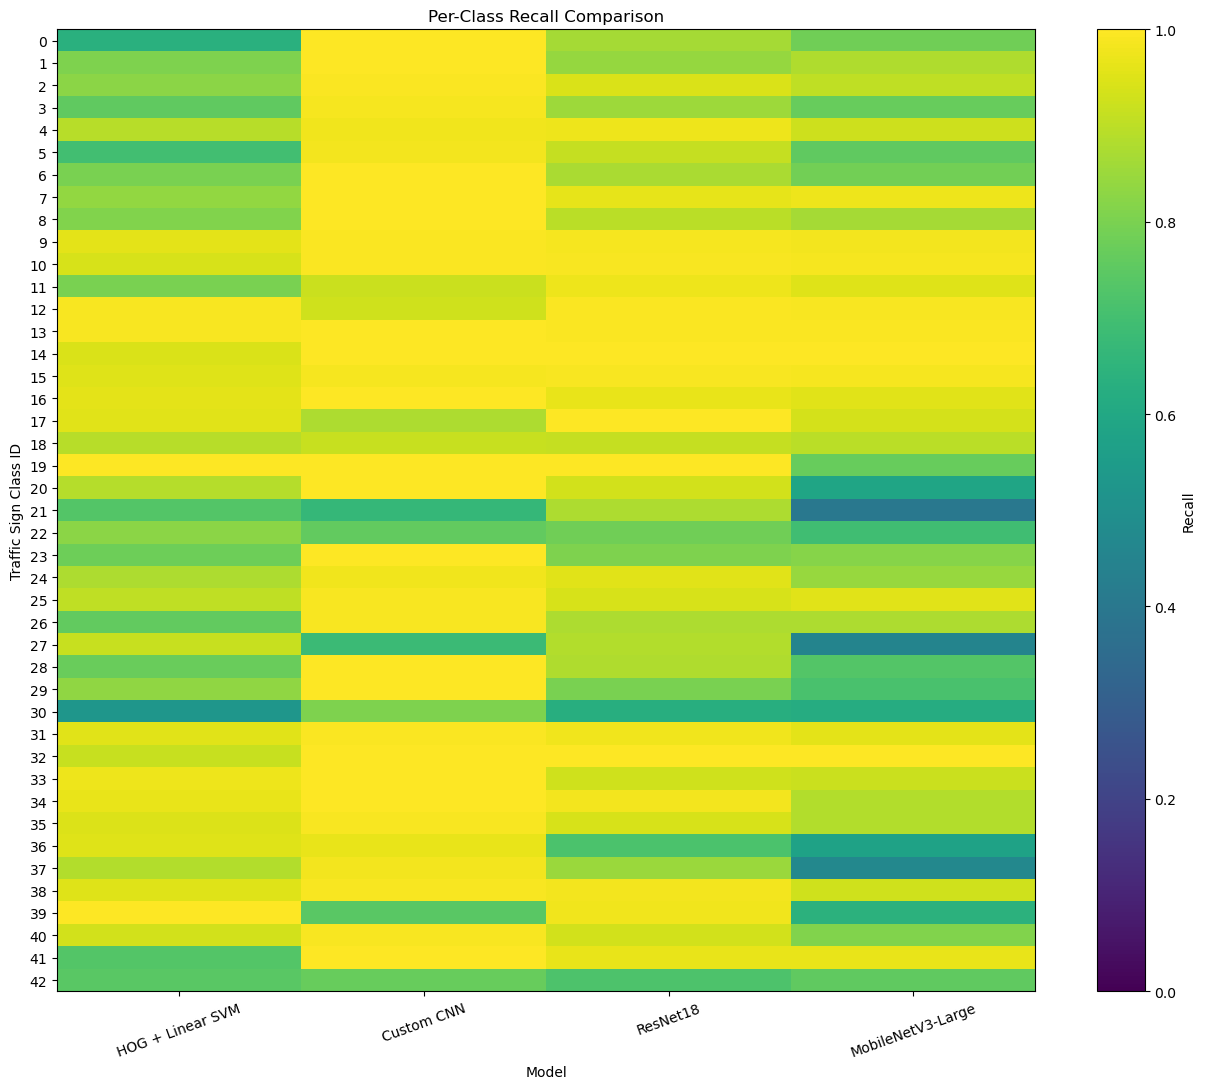

Figure saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/07_per_class_recall_comparison.png


In [30]:
per_class_plot_data = (per_class_comparison.sort_values("class_id").set_index("class_id")[model_recall_columns])

plt.figure(figsize=(13, 11))

image = plt.imshow(per_class_plot_data.values, aspect="auto", vmin=0, vmax=1)

plt.colorbar(image, label="Recall")

plt.title("Per-Class Recall Comparison")

plt.xlabel("Model")
plt.ylabel("Traffic Sign Class ID")

plt.xticks(ticks=np.arange(len(model_recall_columns)), labels=model_recall_columns, rotation=20)

plt.yticks(ticks=np.arange(len(per_class_plot_data.index)), labels=per_class_plot_data.index)

plt.tight_layout()

per_class_heatmap_path = (FIGURES_DIR / "07_per_class_recall_comparison.png")

plt.savefig(per_class_heatmap_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: "f"{per_class_heatmap_path}")

In [31]:
per_class_comparison["best_model_recall"] = (per_class_comparison[model_recall_columns].max(axis=1))

per_class_comparison["worst_model_recall"] = (per_class_comparison[model_recall_columns].min(axis=1))

per_class_comparison["recall_range"] = (per_class_comparison["best_model_recall"] - per_class_comparison["worst_model_recall"])

per_class_comparison["best_model"] = (per_class_comparison[model_recall_columns].idxmax(axis=1))

per_class_comparison["worst_model"] = (per_class_comparison[model_recall_columns].idxmin(axis=1))

largest_differences = (per_class_comparison.sort_values("recall_range", ascending=False).head(10))

display(
    largest_differences[
        [
            "class_id",
            "class_name",
            "support",
            "best_model",
            "best_model_recall",
            "worst_model",
            "worst_model_recall",
            "recall_range"
        ]
    ].round(4)
)

,class_id,class_name,support,best_model,best_model_recall,worst_model,worst_model_recall,recall_range
37,37,37,60,Custom CNN,0.9833,MobileNetV3-Large,0.4667,0.5167
21,21,21,90,ResNet18,0.8778,MobileNetV3-Large,0.4000,0.4778
27,27,27,60,HOG + Linear SVM,0.9167,MobileNetV3-Large,0.4500,0.4667
20,20,20,90,Custom CNN,1.0000,MobileNetV3-Large,0.5889,0.4111
36,36,36,120,Custom CNN,0.9667,MobileNetV3-Large,0.5750,0.3917
0,0,0,60,Custom CNN,1.0000,HOG + Linear SVM,0.6333,0.3667
39,39,39,90,HOG + Linear SVM,1.0000,MobileNetV3-Large,0.6444,0.3556
29,29,29,90,Custom CNN,1.0000,MobileNetV3-Large,0.7111,0.2889
5,5,5,630,Custom CNN,0.9841,HOG + Linear SVM,0.6968,0.2873
30,30,30,150,Custom CNN,0.8067,HOG + Linear SVM,0.5267,0.2800


In [32]:
per_class_comparison_path = (TABLES_DIR / "per_class_recall_comparison.csv")

per_class_comparison.to_csv(per_class_comparison_path,index=False)

print(f"Per-class comparison saved to: "f"{per_class_comparison_path}")

Per-class comparison saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/tables/per_class_recall_comparison.csv


##### Per-Class Interpretation

The class-level results should be interpreted together with class support.

Several lower-frequency classes were more difficult for the models, particularly where only 60–120 test examples were available. MobileNetV3's weakest classes included Classes 37, 27, 21, 36, and 19, with substantially lower F1-scores than its strongest classes.

The custom CNN achieved the highest macro F1-score, indicating that its advantage was not limited to the most frequent classes. It maintained stronger performance across the class set than the other models.

However, class frequency is not the only explanation for poor performance. Some low-frequency classes were recognised successfully, while some more frequent classes remained difficult. Visual similarity, symbol detail, image quality, and confusion between related signs are also important factors.

The table generated above identifies the classes with the largest variation between models. These classes are particularly useful for analysing which visual features were handled differently by the traditional, custom CNN, and transfer learning approaches.

##### 11. Common Classification Errors

The previous experiments saved the most common confusion pairs for HOG-SVM, ResNet18, and MobileNetV3.

These results help identify traffic sign categories that share similar shapes, colours, borders, or internal symbols.

In [33]:
confusion_files = {
    "HOG + Linear SVM":
        RESULTS_DIR
        / "hog_svm_common_classification_errors.csv",

    "ResNet18":
        RESULTS_DIR
        / "resnet18_common_confusions.csv",

    "MobileNetV3-Large":
        RESULTS_DIR
        / "mobilenetv3_common_confusions.csv"
}

common_confusion_data = {}

for model_name, file_path in confusion_files.items():
    if file_path.exists():
        common_confusion_data[model_name] = (pd.read_csv(file_path))

        print(f"Loaded {model_name}: "f"{file_path.name}")
    else:
        print(f"Missing {model_name}: "f"{file_path.name}")

Loaded HOG + Linear SVM: hog_svm_common_classification_errors.csv
Loaded ResNet18: resnet18_common_confusions.csv
Loaded MobileNetV3-Large: mobilenetv3_common_confusions.csv


In [34]:
for model_name, confusion_df in (common_confusion_data.items()):
    print("=" * 75)
    print(model_name)
    print("=" * 75)

    display(confusion_df.head(10))

HOG + Linear SVM


,true_class_name,predicted_class_name,error_count
0,5,2,51
1,1,2,50
2,2,5,42
3,3,2,31
4,3,5,29
5,11,28,25
6,2,1,25
7,3,1,23
8,1,5,22
9,26,25,20


ResNet18


,true_class,predicted_class,count,true_class_rate
0,Class 1,Class 2,90,0.1250
1,Class 5,Class 2,32,0.0508
2,Class 3,Class 2,31,0.0689
3,Class 3,Class 5,28,0.0622
4,Class 30,Class 31,20,0.1333
5,Class 30,Class 20,19,0.1267
6,Class 8,Class 5,19,0.0422
7,Class 42,Class 41,17,0.1889
8,Class 2,Class 1,16,0.0213
9,Class 23,Class 31,15,0.1000


MobileNetV3-Large


,true_original_class,predicted_original_class,true_class_name,predicted_class_name,error_count
0,5,2,Class 5,Class 2,64
1,1,2,Class 1,Class 2,51
2,3,1,Class 3,Class 1,49
3,36,37,Class 36,Class 37,38
4,4,2,Class 4,Class 2,34
5,2,1,Class 2,Class 1,34
6,39,38,Class 39,Class 38,30
7,3,2,Class 3,Class 2,30
8,27,25,Class 27,Class 25,29
9,21,19,Class 21,Class 19,25


##### Error Analysis

The confusion results show that classification errors were concentrated among specific class pairs rather than being distributed uniformly.

Traffic signs are a fine-grained classification problem because many categories share:

- the same circular, triangular, or rectangular shape;
- similar red, blue, white, or yellow colour schemes;
- closely related internal symbols;
- only small differences in numbers, arrows, or pictograms.

The 32 × 32 input resolution used by the custom CNN and HOG-SVM reduces fine detail, but it also preserves a compact representation of the dominant colour and shape information. The custom CNN appears to have learned these task-specific patterns effectively.

The transfer learning models used 224 × 224 inputs and pretrained ImageNet features. These features provide general edge, texture, and object representations, but they were not originally trained to separate highly similar traffic signs. Domain-specific fine-tuning was therefore still required.

MobileNetV3 showed particularly weak performance on several smaller classes. Its macro F1-score suggests that the model was not equally effective across all categories, despite its relatively strong overall accuracy.

##### 12. Why Did the Custom CNN Outperform Transfer Learning?

Transfer learning is often useful when the target dataset is limited, but it is not guaranteed to outperform a model trained from scratch.

Several factors may explain the result in this project.

1. The dataset was sufficiently large

   The training split contained more than 31,000 images. This provided enough examples for a compact CNN to learn useful task-specific representations without relying entirely on pretrained features.

2. Traffic signs have a restricted visual domain

   Traffic signs are dominated by relatively simple features such as colour, border shape, orientation, and internal symbols. A purpose-built CNN may learn these patterns effectively without requiring a very deep architecture.

3. ImageNet differs from the target domain

   ResNet18 and MobileNetV3 were pretrained on ImageNet, which contains natural objects and scenes. Traffic signs are more standardised and fine-grained. General ImageNet features may therefore be less directly transferable than expected.

4. Input resolution and computational setup differed

   The custom CNN used 32 × 32 images, while the transfer learning models used 224 × 224 images. The larger images substantially increased CPU training cost.

5. Fine-tuning was computationally constrained

   Because the models were trained locally on CPU, only a limited number of epochs and fine-tuning configurations could be explored. GPU access would have allowed more extensive hyperparameter tuning and gradual layer unfreezing.

6. The custom CNN may have matched the task complexity better

   The custom CNN contained only about 162,000 parameters. Its smaller capacity may have been sufficient for the structured traffic sign domain while reducing unnecessary model complexity.

##### 13. Final Model Selection

The custom CNN was selected as the final model for this project.

It achieved:

- **96.97% test accuracy**;
- **95.02% macro precision**;
- **95.01% macro recall**;
- **94.74% macro F1-score**;
- approximately **0.162 million parameters**;
- approximately **35.68 minutes of CPU training time**.

It outperformed the HOG-SVM baseline by approximately **9.26 percentage points** in accuracy.

It also outperformed ResNet18 by approximately **3.49 percentage points** and MobileNetV3-Large by approximately **7.90 percentage points**.

The custom CNN was not selected solely because it achieved the highest accuracy. It also provided:

- the highest macro F1-score;
- the smallest neural network parameter count;
- the shortest neural network training time;
- the strongest accuracy-to-complexity trade-off.

ResNet18 was the strongest transfer learning model and remains useful as evidence that pretrained deep features can achieve strong traffic sign recognition. However, it did not outperform the smaller task-specific CNN.

MobileNetV3 was designed as a lightweight architecture, but under the CPU-based experimental setup it did not provide the expected efficiency advantage and achieved lower class-level consistency.

##### 14. Limitations

Several limitations should be considered when interpreting the comparison.

1. CPU-based experimentation

   All deep learning models were trained locally using CPU execution. This limited the number of epochs, hyperparameter combinations, and fine-tuning strategies that could be evaluated.

2. Different input resolutions

    The baseline models used 32 × 32 inputs, while the transfer learning models used 224 × 224 inputs. This means that the training-time comparison reflects the complete modelling pipelines rather than architecture alone.

3. Limited hyperparameter search

    Each model used a relatively small manually selected set of hyperparameters. A larger search might improve the transfer learning results.

4. Single train-validation-test split

   All models used the same fixed split, which supports direct comparison. However, repeated experiments or cross-validation would provide stronger evidence of result stability.

5. Single random seed

   The experiments used a fixed random seed. Neural network results can vary because of parameter initialisation, batch ordering, and augmentation.

6. Pretraining domain mismatch

   ResNet18 and MobileNetV3 were pretrained on ImageNet. The ImageNet domain differs substantially from highly structured, fine-grained traffic sign recognition.

7. Training-time anomalies

   The MobileNetV3 experiment contained an unusually long feature-extraction epoch. Its total training time should therefore be interpreted cautiously and not treated as a general benchmark for the architecture.

8. No deployment-device benchmark

   Inference was measured on the local CPU, but the models were not evaluated on mobile, embedded, or edge hardware. MobileNetV3 may show a stronger efficiency advantage on hardware for which it was specifically designed.

##### 15. Future Work

The project could be extended in several directions.

1. **GPU-based hyperparameter tuning**  
   GPU access would allow more fine-tuning epochs, additional learning rates, and wider architecture comparisons.

2. **Repeated experiments**  
   Running each model with multiple random seeds would provide confidence intervals and a more reliable estimate of performance.

3. **Targeted augmentation**  
   Augmentation could be designed specifically for difficult classes using controlled brightness, blur, rotation, scale, and perspective transformations.

4. **Class imbalance strategies**  
   Weighted loss functions, balanced sampling, or targeted data collection could improve performance for lower-frequency classes.

5. **Higher-resolution custom CNN**  
   The custom CNN could be tested with moderately larger inputs, such as 48 × 48 or 64 × 64, to preserve fine symbol details without the full cost of 224 × 224 inputs.

6. **Progressive transfer learning**  
   More gradual layer unfreezing and discriminative learning rates could improve ResNet18 or MobileNetV3 adaptation.

7. **Alternative lightweight models**  
   Architectures such as EfficientNet-B0 could be evaluated if additional computational resources become available.

8. **Model explainability**  
   Grad-CAM or similar visualisation methods could show whether the CNN focuses on the relevant traffic sign symbols and borders.

9. **Real-world testing**  
   The final model could be evaluated on images with motion blur, poor lighting, occlusion, unusual viewing angles, or cluttered backgrounds.

10. **Deployment evaluation**  
    Model size, memory use, and latency could be measured on mobile or embedded hardware.

##### 16. Final Summary

This notebook compared HOG + Linear SVM, a custom CNN, ResNet18, and MobileNetV3-Large on the same traffic sign test set.

The main findings were:

- the custom CNN achieved the highest test accuracy of **96.97%**;
- the custom CNN achieved the highest macro F1-score of **94.74%**;
- ResNet18 was the strongest transfer learning model, with **93.48% accuracy**;
- MobileNetV3 achieved **89.07% accuracy**, but its lower macro F1-score indicated less consistent class-level performance;
- transfer learning did not outperform the custom CNN in this experiment;
- the custom CNN contained substantially fewer parameters than both pretrained models;
- the custom CNN required the shortest neural network training time;
- the custom CNN provided the strongest balance between accuracy, class-level consistency, model size, and computational cost.

Overall, the experiments demonstrate that transfer learning is a valuable approach but is not automatically the best solution for every image classification problem. For this traffic sign dataset, a compact task-specific CNN provided the most effective and practical model.

In [35]:
raw_results_path = (TABLES_DIR / "all_model_results.csv")

ranking_table_path = (TABLES_DIR / "model_ranking.csv")

improvement_table_path = (TABLES_DIR / "improvement_over_hog_svm.csv")

results_df.to_csv(raw_results_path, index=False)

ranking_display.to_csv(ranking_table_path, index=False)

improvement_df.to_csv(improvement_table_path, index=False)

print("Final tables saved")
print("-" * 70)
print(raw_results_path)
print(performance_table_path)
print(ranking_table_path)
print(improvement_table_path)
print(efficiency_table_path)
print(per_class_comparison_path)

Final tables saved
----------------------------------------------------------------------
/Users/liuyuhan/Desktop/traffic_recognition/results/tables/all_model_results.csv
/Users/liuyuhan/Desktop/traffic_recognition/results/tables/overall_model_performance.csv
/Users/liuyuhan/Desktop/traffic_recognition/results/tables/model_ranking.csv
/Users/liuyuhan/Desktop/traffic_recognition/results/tables/improvement_over_hog_svm.csv
/Users/liuyuhan/Desktop/traffic_recognition/results/tables/model_efficiency_comparison.csv
/Users/liuyuhan/Desktop/traffic_recognition/results/tables/per_class_recall_comparison.csv


In [36]:
print("Generated comparison figures")
print("=" * 70)

comparison_figures = sorted(FIGURES_DIR.glob("07_*.png"))

for file_path in comparison_figures:
    print(f"FOUND | {file_path.name}")

print("\nGenerated comparison tables")
print("=" * 70)

comparison_tables = sorted(TABLES_DIR.glob("*.csv"))

for file_path in comparison_tables:
    print(f"FOUND | {file_path.name}")

print("\nNotebook 07 completed successfully.")

Generated comparison figures
FOUND | 07_accuracy_complexity_tradeoff.png
FOUND | 07_model_complexity_comparison.png
FOUND | 07_overall_performance_comparison.png
FOUND | 07_per_class_recall_comparison.png
FOUND | 07_test_accuracy_comparison.png
FOUND | 07_training_time_comparison.png

Generated comparison tables
FOUND | all_model_results.csv
FOUND | improvement_over_hog_svm.csv
FOUND | model_efficiency_comparison.csv
FOUND | model_ranking.csv
FOUND | overall_model_performance.csv
FOUND | per_class_recall_comparison.csv

Notebook 07 completed successfully.
